<hr>
<center> Coding Exercise for Control Systems<br>
<b> Exercise 6: I/O Maps and Frequency Domain </b> <br>
Prof. Dr. Florian Dörfler <br>
Automatic Control Laboratory, ETH Zurich </center>
<hr>

In this notebook, we learn about responses to LTI systems and BIBO stability.

<blockquote>
<b>Activity:</b> Execute the code cells below so that the necessary libraries get imported.
</blockquote>

In [1]:
# !pip install control

In [2]:
import numpy as np # the standard library for numerics, vectors, matrices
import control as ct # the standard library for basic operations for analysis and design of feedback control systems
import matplotlib.pyplot as plt # a comprehensive library for creating static, animated, and interactive visualizations

<b> C 6.1: Bode plot </b>

Consider a system with the following transfer function:

\begin{align*}
G(s) = \frac{0.1s+1}{s(s+1)(0.02s+1)^2}
\end{align*}

<blockquote>
<b>Activity:</b> Complete the code fragment below to generate the Bode plot of this system.
</blockquote>

In [8]:
np.polymul(np.polymul([1, 0], [1, 1]), np.polymul([0.02, 1], [0.02, 1]))

array([4.00e-04, 4.04e-02, 1.04e+00, 1.00e+00, 0.00e+00])

System Transfer Function G(s) =
<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                0.1 s + 1
  --------------------------------------
  0.0004 s^4 + 0.0404 s^3 + 1.04 s^2 + s

--- Generating Bode Plot ---


c:\Users\pere\Documents\programming\mas_assignments\control\.venv\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


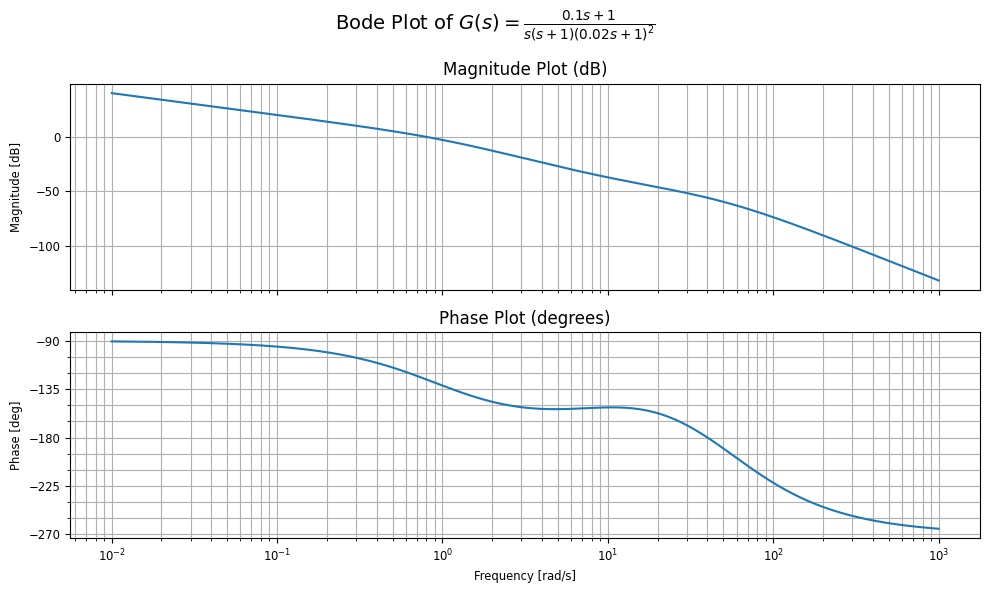

In [13]:
# Define the Transfer Function G(s)
num_coeffs = [0.1, 1]
den_coeffs = np.polymul(np.polymul([1, 0], [1, 1]), np.polymul([0.02, 1], [0.02, 1]))  # s(s+1)(0.02s+1)^2

# Create the Transfer Function object
G = ct.tf(num_coeffs, den_coeffs)

print('System Transfer Function G(s) =')
print(G)
print('\n--- Generating Bode Plot ---')

omega = np.logspace(-2, 3, 500)

plt.figure(figsize=(10, 6))
out = ct.bode_plot(G, omega, dB=True, Hz=False, deg=True, plot=True)

plt.suptitle(r'Bode Plot of $G(s) = \frac{0.1s+1}{s(s+1)(0.02s+1)^2}$', fontsize=14)

plt.gcf().axes[0].set_title('Magnitude Plot (dB)')
plt.gcf().axes[1].set_title('Phase Plot (degrees)')
plt.tight_layout()

plt.show()

<br>

<b> C 6.2: Impulse and Step Response in Discrete Time </b>

Consider the discrete-time linear time-invariant system <br>
\begin{equation*}
\begin{split}
x_{k+1} = A_\mathrm{d}x_k+B_\mathrm{d}u_k \\
y_k = C_\mathrm{d}x_k+D_\mathrm{d}u_k
\end{split}
\end{equation*}
with the system matrices
\begin{equation*}
A_\mathrm{d} = \begin{bmatrix} -0.4& 2.3& -4.5\\ 0.4& -1.3& 4.5\\ 0.4&-1.3&3.5\end{bmatrix}, \, B_\mathrm{d} = \begin{bmatrix} -1\\1\\1\end{bmatrix},\\
C_\mathrm{d} = \begin{bmatrix} 0.84& -1.9& 3.74\end{bmatrix}, \, D_\mathrm{d}=0.
\end{equation*}
The sampling time is specified as $T=1$ second. Assume the initial condition to be zero.

<blockquote>
<b>Activity:</b> Complete the code fragment below to compute and plot the step and impulse responses (output $y_k$) and the corresponding evolution of the three states $x_k$ over the interval from 0 to 30 seconds.
</blockquote>

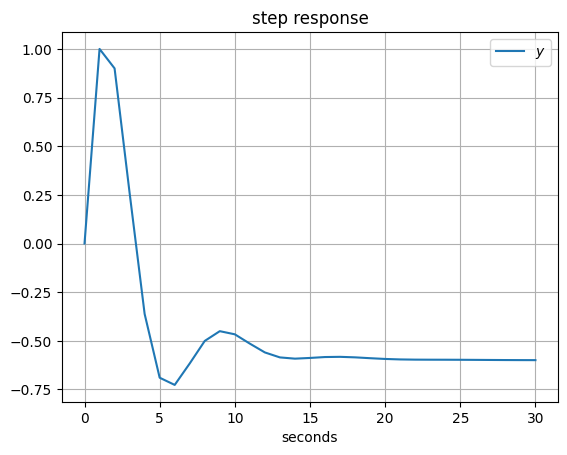

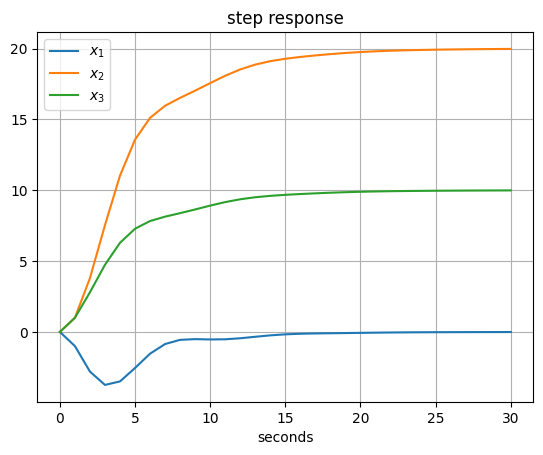

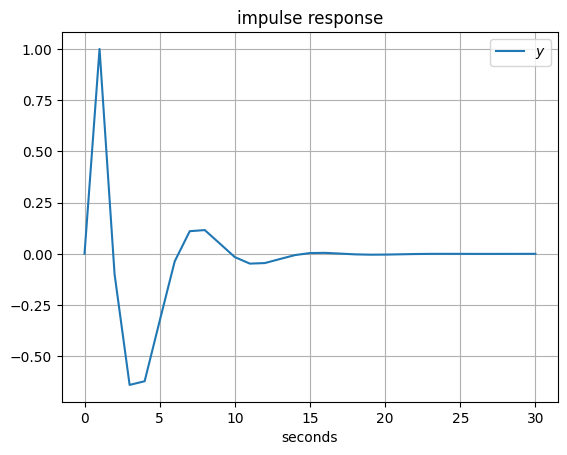

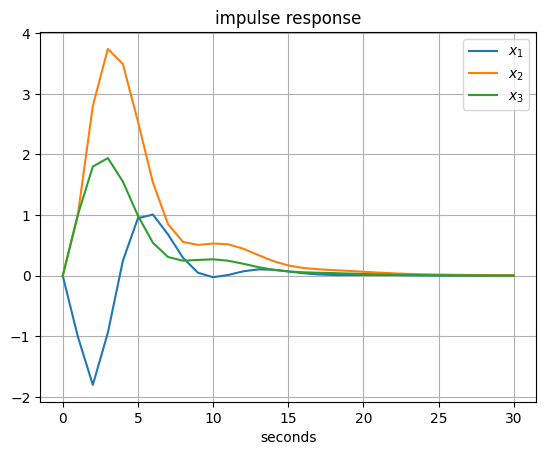

In [15]:
#system matrices
A_d = np.array([[-0.4, 2.3, -4.5],
                [0.4, -1.3, 4.5],
                [0.4, -1.3, 3.5]])
B_d = np.array([[-1],
                [1],
                [1]])
C_d = np.array([[0.84, -1.9, 3.74]])
D_d = np.array([[0]])

#sampling time [sec]
T_s = 1
#final time [sec]
T_final = 30

#define discrete-time state-space object
sys = ct.ss(A_d,B_d,C_d,D_d,T_s)
sys

#compute step and impulse response
t_step,y_step,x_step = ct.step_response(sys, T=T_final, return_x=True)
t_impulse,y_impulse,x_impulse = ct.impulse_response(sys, T=T_final, return_x=True)

#plots
plt.plot(t_step,y_step,label='$y$')
plt.xlabel("seconds")
plt.title("step response")
plt.legend()
plt.grid()
plt.show()

plt.plot(t_step,x_step[0],label='$x_1$')
plt.plot(t_step,x_step[1],label='$x_2$')
plt.plot(t_step,x_step[2],label='$x_3$')
plt.xlabel("seconds")
plt.title("step response")
plt.legend()
plt.grid()
plt.show()

plt.plot(t_impulse,y_impulse,label='$y$')
plt.xlabel("seconds")
plt.title("impulse response")
plt.legend()
plt.grid()
plt.show()

plt.plot(t_impulse,x_impulse[0],label='$x_1$')
plt.plot(t_impulse,x_impulse[1],label='$x_2$')
plt.plot(t_impulse,x_impulse[2],label='$x_3$')
plt.xlabel("seconds")
plt.title("impulse response")
plt.legend()
plt.grid()
plt.show()



<br>

<b> C 6.3: Internal Stability vs. BIBO Stability </b>

First, consider the continuous-time state-space system 
\begin{equation*}
\begin{split}
\dot{x} &= \begin{bmatrix} 0&1\\-1&-2\end{bmatrix}x+\begin{bmatrix} 0\\-1\end{bmatrix}u\\
y &= \begin{bmatrix} -1& 2\end{bmatrix}x.
\end{split}
\end{equation*}

<blockquote>
<b>Activity:</b> Complete the code fragment below and check if the system is internally stable?
</blockquote>

In [17]:
#system matrix
A1 = np.array([[0, 1],[-1, -2]])
B1 = np.array([[0],[-1]])
C1 = np.array([[-1, 2]])
D1 = np.array([[0]])

#check internal stability of the system
# sys1 = ct.ss(A1,B1,C1,D1)
eigen = np.linalg.eigvals(A1)  #eigenvalues of A1
print("eigenvalues of A1:", eigen)
if np.all(np.real(eigen) < 0):
    print("The system is internally stable.")
else:
    print("The system is internally unstable.")

eigenvalues of A1: [-1. -1.]
The system is internally stable.


<i> Answer on internal stability of the system </i>: . . .

<blockquote>
<b>Activity:</b> Complete the code fragment below and compute the transfer function of the above state-space system. Check if there are pole-zero cancellations. What can you conclude on the BIBO stability of the system?
</blockquote>

In [21]:
#compute transfer function
sys_tf = ct.ss2tf(A1,B1,C1,D1)
print("Transfer Function G1(s) =")
print(sys_tf)

Transfer Function G1(s) =
<TransferFunction>: sys[14]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    -2 s + 1
  -------------
  s^2 + 2 s + 1


<i> Conclusion on BIBO stability of the system: </i> . . .

<br>

Next, consider the continuous-time state-space system 
\begin{equation*}
\begin{split}
\dot{x} &= \begin{bmatrix} -1&0\\5&1\end{bmatrix}x+\begin{bmatrix} 1\\1\end{bmatrix}u\\
y &= \begin{bmatrix} 1& 0\end{bmatrix}x.
\end{split}
\end{equation*}

<blockquote>
<b>Activity:</b> Complete the code fragment below and check if the system is internally stable?
</blockquote>

In [22]:
#system matrix
A2 = np.array([[-1, 0],[5, 1]])
B2 = np.array([[1],[1]])
C2 = np.array([[1, 0]])
D2 = np.array([[0]])

#check internal stability of the system
w, v = np.linalg.eig(A2)
print("eigenvalues of A2:", w)
if np.all(np.real(w) < 0):
    print("The system is asymptotically stable.")
else:
    print("The system is internally unstable.")

eigenvalues of A2: [ 1. -1.]
The system is internally unstable.


<i> Answer on internal stability of the system: </i> . . .

<blockquote>
<b>Activity:</b> Complete the code fragment below and compute the transfer function of the above state-space system. Check if there are pole-zero cancellations. What can you conclude on the BIBO stability of the system?
</blockquote>

In [23]:
#compute transfer function
sys2 = ct.ss2tf(A2,B2,C2,D2)
print("Transfer Function G2(s) =")
print(sys2)

Transfer Function G2(s) =
<TransferFunction>: sys[16]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   s - 1
  -------
  s^2 - 1


<i> Conclusion on BIBO stability of the system: </i> . . .